This notebook performs a brief exploratory data analysis of the Retailrocket dataset to understand user interactions, item metadata, and temporal patterns before building the recommendation system.

The dataset contains three main components:

- Events: user interactions with items (view, add-to-cart, transaction)
- Item Properties: metadata describing items and their attributes
- Category Tree: hierarchical structure of item categories

1. Load data

In [3]:
import pandas as pd

events = pd.read_csv("../Data/events.csv")

p1 = pd.read_csv("../Data/item_properties_part1.csv")
p2 = pd.read_csv("../Data/item_properties_part2.csv")

item_props = pd.concat([p1, p2])

category_tree = pd.read_csv("../Data/category_tree.csv")

print(events.shape)
print(item_props.shape)
print(category_tree.shape)

(2756101, 5)
(20275902, 4)
(1669, 2)


2. Basic statistics

In [6]:
print(events.head())
print()
print(item_props.head())
print()
print(category_tree.head())

       timestamp  visitorid event  itemid  transactionid
0  1433221332117     257597  view  355908            NaN
1  1433224214164     992329  view  248676            NaN
2  1433221999827     111016  view  318965            NaN
3  1433221955914     483717  view  253185            NaN
4  1433221337106     951259  view  367447            NaN

       timestamp  itemid    property                            value
0  1435460400000  460429  categoryid                             1338
1  1441508400000  206783         888          1116713 960601 n277.200
2  1439089200000  395014         400  n552.000 639502 n720.000 424566
3  1431226800000   59481         790                       n15360.000
4  1431831600000  156781         917                           828513

   categoryid  parentid
0        1016     213.0
1         809     169.0
2         570       9.0
3        1691     885.0
4         536    1691.0


In [7]:
print("Users:", events["visitorid"].nunique())
print("Items:", events["itemid"].nunique())
print("Events:", len(events))

Users: 1407580
Items: 235061
Events: 2756101


3. Implicit feedback distribution

event
view           0.966696
addtocart      0.025156
transaction    0.008148
Name: proportion, dtype: float64


<Axes: xlabel='event'>

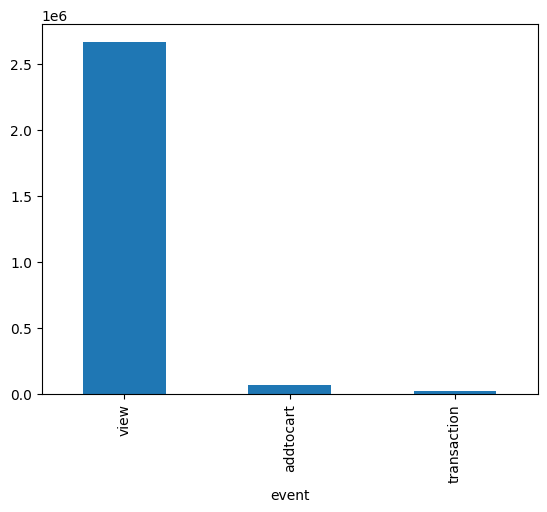

In [11]:
print(events["event"].value_counts(normalize=True))
events["event"].value_counts().plot(kind="bar")

Event distribution analysis shows that most interactions are views (96.7%),  while add-to-cart (2.5%) and purchases (0.8%) are much rarer.
This indicates that the dataset represents implicit feedback behavior. 
Therefore, all interaction types will be treated as positive signals, with optional weighting to reflect different engagement levels.

4. Timeline of dataset

2015-05-03 03:00:04.384000 2015-09-18 02:59:47.788000


<Axes: xlabel='timestamp'>

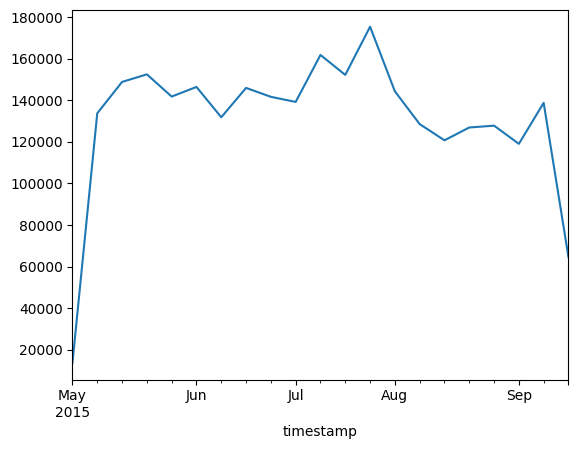

In [14]:
events["timestamp"] = pd.to_datetime(events["timestamp"], unit="ms")

print(events["timestamp"].min(), events["timestamp"].max())

events.set_index("timestamp").resample("W").size().plot()

Weekly event counts (views, add-to-cart, and transactions) are generally stable between 120k–170k events per week from May to September 2015. Activity peaks around late July, indicating the highest user engagement during this period. The first and last weeks show unusually low counts, likely due to incomplete data for those weeks rather than actual drops in activity.

5. User activity distribution

In [19]:
user_activity = events.groupby("visitorid").size()

user_activity.describe()


count    1.407580e+06
mean     1.958042e+00
std      1.258049e+01
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      2.000000e+00
max      7.757000e+03
dtype: float64

Most users have very few interactions (long-tail distribution).

6. Sparity of interaction matrix

In [20]:
num_users = events["visitorid"].nunique()
num_items = events["itemid"].nunique()
num_interactions = len(events)

sparsity = 1 - num_interactions / (num_users * num_items)

print("Sparsity:", sparsity)

Sparsity: 0.9999916700678901


Interaction matrix is extremely sparse (>99%).

7. Item popularity

In [27]:
item_popularity = events.groupby("itemid").size()

print(item_popularity.describe())

count    235061.000000
mean         11.725046
std          37.032101
min           1.000000
25%           1.000000
50%           3.000000
75%           9.000000
max        3412.000000
dtype: float64


A small number of items receive most interactions.

In [24]:
print(events.isnull().sum())
print(events.duplicated().sum())

timestamp              0
visitorid              0
event                  0
itemid                 0
transactionid    2733644
dtype: int64
460


8. Key observations:

- Dataset contains 1407580 users and 235061 items with 2756101 interactions.
- User-item interaction matrix is highly sparse.
- View events dominate (>90%).
- Item popularity follows a long-tail distribution.
- Dataset spans from DATE to DATE, enabling temporal split.

In [6]:
import pandas as pd

df = pd.read_csv("..\\Data\\raw\\category_tree.csv")

# build tree
tree = df.groupby("parentid")["categoryid"].apply(list).to_dict()

def write_tree(parent, level, file):
    for child in tree.get(parent, []):
        line = " " * level * 4 + str(child)
        file.write(line + "\n")
        write_tree(child, level + 1, file)

# tìm root nodes
roots = df[df["parentid"].isna()]["categoryid"]

with open("category_tree_output.txt", "w", encoding="utf-8") as f:
    for root in roots:
        f.write(str(root) + "\n")
        write_tree(root, 1, f)

print("Done! File saved: category_tree_output.txt")

Done! File saved: category_tree_output.txt
